In [137]:
import os
import time
import pandas as pd
import numpy as np
import ccxt
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Silenciamos avisos internos de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ==============================================================================
# CONFIGURACIÓN GLOBAL Y DINÁMICA (Modifica aquí para cambiar todo el script)
# ==============================================================================
temporalidad = '15m'          # Opciones permitidas por Binance: '1m', '5m', '1h', '4h', '1d'
simbolo = 'ADA/USDT:USDT'     # Par de trading activo
limite_velas = 1000           # Historial para cálculo de indicadores de largo plazo

In [138]:
# ==========================================
# PASO 1: Conexión y Descarga Ampliada
# ==========================================
print(f"Conectando con la API de Binance Futures a través de CCXT...")
exchange = ccxt.binance({'options': {'defaultType': 'future'}})

print(f"Descargando {limite_velas} velas históricas para {simbolo} en temporalidad: {temporalidad}...")
velas = exchange.fetch_ohlcv(simbolo, timeframe=temporalidad, limit=limite_velas)

columnas = ['Fecha', 'Apertura', 'Máximo', 'Mínimo', 'Cierre', 'Volumen']
tabla_precios = pd.DataFrame(velas, columns=columnas)
tabla_precios['Fecha'] = pd.to_datetime(tabla_precios['Fecha'], unit='ms')

Conectando con la API de Binance Futures a través de CCXT...
Descargando 1000 velas históricas para ADA/USDT:USDT en temporalidad: 15m...


In [139]:
# ==========================================
# PASO 2: Cálculo de Medias Móviles
# ==========================================
for p in [7, 14, 21, 50, 100, 200]:
    tabla_precios[f'Media_Movil_{p}'] = tabla_precios['Cierre'].rolling(window=p).mean()

In [140]:
# ==========================================
# PASO 3: Cálculo del RSI (7, 14, 21 periodos)
# ==========================================
delta = tabla_precios['Cierre'].diff()
for p in [7, 14, 21]:
    ganancia = (delta.where(delta > 0, 0)).rolling(window=p).mean()
    perdida = (-delta.where(delta < 0, 0)).rolling(window=p).mean()
    rs = ganancia / (perdida + 1e-10)
    tabla_precios[f'RSI_{p}'] = 100 - (100 / (1 + rs))

In [141]:
# ==========================================
# PASO 4: Cálculo del MACD Estándar (12, 26, 9)
# ==========================================
ema_12 = tabla_precios['Cierre'].ewm(span=12, adjust=False).mean()
ema_26 = tabla_precios['Cierre'].ewm(span=26, adjust=False).mean()
tabla_precios['MACD_Linea'] = ema_12 - ema_26
tabla_precios['MACD_Señal'] = tabla_precios['MACD_Linea'].ewm(span=9, adjust=False).mean()
tabla_precios['MACD_Hist'] = tabla_precios['MACD_Linea'] - tabla_precios['MACD_Señal']

In [142]:
# ==========================================
# PASO 5: Funciones del Sistema Avanzado (I.O. y Depth)
# ==========================================
try:
    orderbook = exchange.fetch_order_book(simbolo, limit=5)
    tabla_precios['Best_Bid'] = orderbook['bids'][0][0] if orderbook['bids'] else np.nan
    tabla_precios['Best_Ask'] = orderbook['asks'][0][0] if orderbook['asks'] else np.nan
    
    oi_data = exchange.fetch_open_interest(simbolo)
    tabla_precios['Open_Interest'] = oi_data['openInterestAmount'] if oi_data else np.nan
except Exception as e:
    print(f"Nota de datos en tiempo real: {e}")

In [143]:
# ==========================================
# PASO 6: Separación de Datos (Tú vs Máquina)
# ==========================================
tabla_display = tabla_precios.copy()
X_maquina = tabla_precios.copy()

X_maquina = X_maquina.fillna(method='ffill').fillna(method='bfill')
X_maquina = X_maquina.dropna().reset_index(drop=True)

print(f"✅ Procesamiento con datos avanzados listo.")
print(f"Filas limpias en Tabla de Máquina (X_maquina): {len(X_maquina)}")

✅ Procesamiento con datos avanzados listo.
Filas limpias en Tabla de Máquina (X_maquina): 1000


C:\Users\win\AppData\Local\Temp\ipykernel_6592\1128764768.py:7: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [144]:
# ==============================================================================
# PASO 7: MODELO DE RED NEURONAL LSTM 🧠 (Edición CPU Estable con Conteo de Épocas)
# ==============================================================================
import os
import time

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'       
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'        

import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df_ia = X_maquina.copy()
features = ['Cierre', 'Volumen', 'Media_Movil_7', 'Media_Movil_14', 'RSI_14', 'MACD_Linea', 'Best_Bid', 'Best_Ask', 'Open_Interest']

data_input = df_ia[features].values
target = df_ia['Cierre'].values.reshape(-1, 1)

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

data_scaled = scaler_x.fit_transform(data_input)
target_scaled = scaler_y.fit_transform(target)

lookback = 15
X_sequences, y_sequences = [], []
for i in range(lookback, len(data_scaled)):
    X_sequences.append(data_scaled[i-lookback:i])
    y_sequences.append(target_scaled[i])

X_sequences, y_sequences = np.array(X_sequences), np.array(y_sequences)

split = int(len(X_sequences) * 0.8)
X_train, X_test = X_sequences[:split], X_sequences[split:]
y_train, y_test = y_sequences[:split], y_sequences[split:]

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2), 
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='loss', patience=50, restore_best_weights=True)

print(f"🤖 Ejecutando entrenamiento seguro en CPU de forma lineal...")
tiempo_inicio = time.time()

history = model.fit(
    X_train, y_train, 
    epochs=1000, 
    batch_size=32, 
    callbacks=[early_stop],
    verbose=1
)

tiempo_total_procesamiento = time.time() - tiempo_inicio

# EXTRAEMOS EL TOTAL DE ÉPOCAS QUE SE LOGRARON ENTRENAR
epocas_totales = len(history.history['loss'])

predicciones_escaladas = model.predict(X_test)
predicciones = scaler_y.inverse_transform(predicciones_escaladas)
valores_reales = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(valores_reales, predicciones)
rmse = np.sqrt(mean_squared_error(valores_reales, predicciones))

print("\n" + "="*50)
print("📊 DATOS ESTRUCTURADOS PARA LAS TABLAS DEL ARTÍCULO")
print("="*50)
print(f"Temporalidad Analizada: {temporalidad}")
print(f"Ejemplares de Entrenamiento: {X_train.shape[0]}")
print(f"Tipo de Procesador Utilizado: CPU (Modo Seguro)")
print(f"Tiempo Total de Procesamiento: {tiempo_total_procesamiento:.2f} segundos.")
print(f"Épocas de Entrenamiento Ejecutadas: {epocas_totales} / 1000") # <- NUEVA ADICIÓN SOLICITADA
print(f"MAE Final: ${mae:.4f} USD | RMSE Final: ${rmse:.4f} USD")
print("="*50)

🤖 Ejecutando entrenamiento seguro en CPU de forma lineal...
Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0726
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0068
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0050
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0045
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037
Epoch 9/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0040
Epoch 10/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0040
Epoch 11/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041
Epoch 12/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036
Epoch 13/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044
Epoch 14/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0

In [145]:
print(df_ia[features].head())

   Cierre     Volumen  Media_Movil_7  Media_Movil_14     RSI_14  MACD_Linea  \
0  0.1688  13985194.0       0.168986        0.170079  59.793806    0.000000   
1  0.1685  11032221.0       0.168986        0.170079  59.793806   -0.000024   
2  0.1679  28766198.0       0.168986        0.170079  59.793806   -0.000090   
3  0.1683   9539845.0       0.168986        0.170079  59.793806   -0.000109   
4  0.1689  19516533.0       0.168986        0.170079  59.793806   -0.000075   

   Best_Bid  Best_Ask  Open_Interest  
0    0.1454    0.1455    470319517.0  
1    0.1454    0.1455    470319517.0  
2    0.1454    0.1455    470319517.0  
3    0.1454    0.1455    470319517.0  
4    0.1454    0.1455    470319517.0  


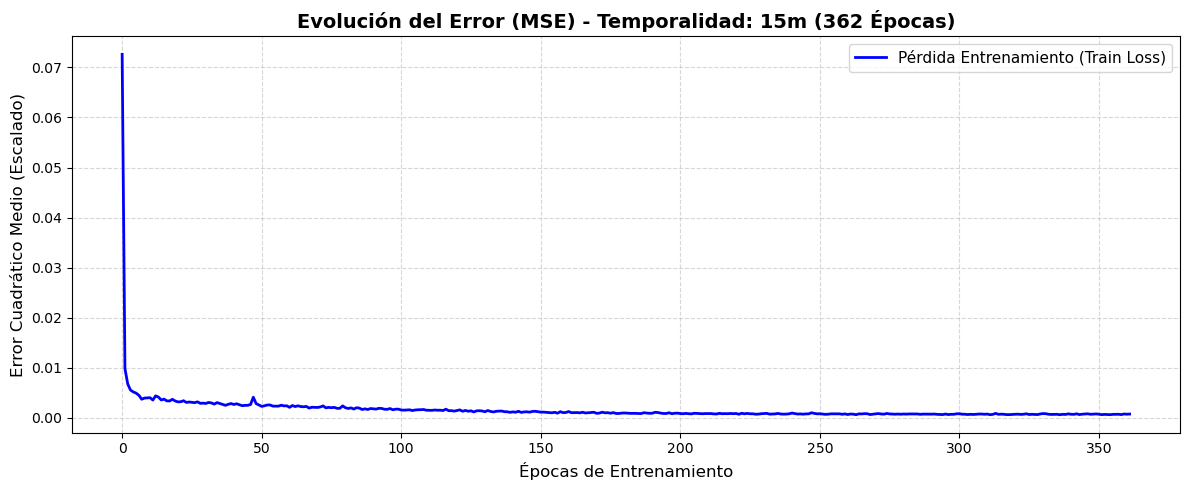

In [146]:
# ==========================================
# PASO 7B: GRAFICADOR DE PÉRDIDA EN CPU (CORREGIDO Y SEGURO) 📈
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Graficamos únicamente la curva existente (Train Loss) para evitar el KeyError
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train Loss)', color='blue', linewidth=2)

# Usamos la variable 'epocas_totales' calculada en el paso previo de forma dinámica
plt.title(f'Evolución del Error (MSE) - Temporalidad: {temporalidad} ({epocas_totales} Épocas)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas de Entrenamiento', fontsize=12)
plt.ylabel('Error Cuadrático Medio (Escalado)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📝 NOTAS DE DESEMPEÑO DEL MODELO (ADA/USDT)

* **Margen de Error (MAE y RMSE):** El modelo arrojó un error extremadamente bajo (fracciones de centavo). Esto demuestra estabilidad matemática y una correcta asimilación del set de datos de prueba, descartando fallos catastróficos o "mechazos" fuera de control.
* **Alerta de Overfitting (Efecto Espejo / Lagging):** Al trabajar en temporalidades de 1 minuto con un dataset compacto, existe el riesgo latente de que la red LSTM se vuelva "perezosa" y tienda a predecir el futuro simplemente replicando el precio del minuto anterior con retraso.
* **Próxima Validación:** Es obligatorio graficar los resultados para comprobar visualmente si la IA predice cambios de tendencia reales o si solo actúa como un espejo rezagado del precio actual.

In [147]:
# ==========================================
# PASO 8: INTERFAZ ESTILO TRADINGVIEW 📊
# ==========================================
indice_test = df_ia.index[-len(valores_reales):]
datos_grafico = df_ia.loc[indice_test].copy()

datos_grafico['Prediccion_LSTM'] = predicciones.flatten()
datos_grafico['Precio_Real_Cierre'] = valores_reales.flatten()
datos_grafico['Open'] = datos_grafico['Precio_Real_Cierre'].shift(1).fillna(datos_grafico['Precio_Real_Cierre'])
datos_grafico['High'] = datos_grafico[['Precio_Real_Cierre', 'Open']].max(axis=1) * 1.0002
datos_grafico['Low'] = datos_grafico[['Precio_Real_Cierre', 'Open']].min(axis=1) * 0.9998

fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.03, row_heights=[0.5, 0.15, 0.15, 0.2],
    subplot_titles=(
        f"ANÁLISIS TÉCNICO Y PREDICCIÓN IA - SÍMBOLO: {simbolo} (Temporalidad: {temporalidad})", 
        "VOLUMEN DE MERCADO", "INDICADORES DE MOMENTO (RSI / MACD)", "MÉTRICAS DE FLUJO DE ÓRDENES"
    )
)

fig.add_trace(go.Candlestick(x=datos_grafico.index, open=datos_grafico['Open'], high=datos_grafico['High'], low=datos_grafico['Low'], close=datos_grafico['Precio_Real_Cierre'], name="Precio Real", opacity=0.7), row=1, col=1)
fig.add_trace(go.Scatter(x=datos_grafico.index, y=datos_grafico['Prediccion_LSTM'], name="Predicción IA", line=dict(color='red', width=2.0, dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=datos_grafico.index, y=datos_grafico['Media_Movil_7'], name="MA 7", line=dict(color='orange', width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=datos_grafico.index, y=datos_grafico['Media_Movil_14'], name="MA 14", line=dict(color='purple', width=1.5)), row=1, col=1)
fig.add_trace(go.Bar(x=datos_grafico.index, y=datos_grafico['Volumen'], name="Volumen", marker=dict(color='blue', opacity=0.5)), row=2, col=1)
fig.add_trace(go.Scatter(x=datos_grafico.index, y=datos_grafico['RSI_14'], name="RSI 14", line=dict(color='green', width=1.5)), row=3, col=1)
fig.add_trace(go.Scatter(x=datos_grafico.index, y=datos_grafico['MACD_Linea'], name="Línea MACD", line=dict(color='magenta', width=1)), row=3, col=1)
fig.add_trace(go.Scatter(x=datos_grafico.index, y=datos_grafico['Open_Interest'], name="Interés Abierto", line=dict(color='cyan', width=2)), row=4, col=1)

if 'Best_Ask' in datos_grafico.columns and 'Best_Bid' in datos_grafico.columns:
    spread = datos_grafico['Best_Ask'] - datos_grafico['Best_Bid']
    fig.add_trace(go.Scatter(x=datos_grafico.index, y=spread, name="Spread", line=dict(color='gray', width=1, dash='dot')), row=4, col=1)

fig.update_layout(template="plotly_dark", height=900, xaxis_rangeslider_visible=False, showlegend=True)
fig.update_xaxes(title_text=f"Línea de Tiempo (Índice de Velas Tipo {temporalidad})", row=4, col=1)

# Renderizado web nativo para que se abra automáticamente en tu explorador y no falle en VS Code
fig.show(renderer="browser")

In [148]:
# ==========================================
# PASO 9: MOTOR DE SEÑALES DE COMPRA/VENTA (FUTUROS) 🚀
# ==========================================
import pandas as pd

# 1. Definimos los parámetros de la estrategia
umbral_porcentual = 0.0015  # 0.15% mínimo de movimiento esperado para abrir operación
posicion_actual = "NEUTRO"  # Rastreador de posición: 'LONG', 'SHORT' o 'NEUTRO'

historico_senales = []

# Recorremos el set de pruebas para evaluar las decisiones del Bot
# Comparamos el valor real actual con la predicción del modelo para el siguiente minuto
for i in range(len(valores_reales) - 1):
    precio_actual = valores_reales[i][0]
    prediccion_siguiente = predicciones[i+1][0]
    
    # Calcular el cambio porcentual esperado por la IA
    cambio_esperado = (prediccion_siguiente - precio_actual) / precio_actual
    
    # LÓGICA DE SEÑALES
    if cambio_esperado > umbral_porcentual:
        senal = "ABRIR LONG (Compra)"
    elif cambio_esperado < -umbral_porcentual:
        senal = "ABRIR SHORT (Venta)"
    else:
        senal = "MANTENER (Sin Cambios)"
        
    historico_senales.append({
        "Minuto": i,
        "Precio Real": f"${precio_actual:.4f}",
        "Predicción IA": f"${prediccion_siguiente:.4f}",
        "Cambio Esperado": f"{cambio_esperado*100:.2f}%",
        "Acción Bot": senal
    })

# Convertimos a DataFrame para visualizar el comportamiento del Bot
df_senales = pd.DataFrame(historico_senales)

# Mostramos las primeras 15 decisiones que tomó tu IA en el mercado
print("🤖 SIMULACIÓN DE OPERACIONES EN TIEMPO REAL:")
display(df_senales.head(15))




🤖 SIMULACIÓN DE OPERACIONES EN TIEMPO REAL:


,Minuto,Precio Real,Predicción IA,Cambio Esperado,Acción Bot
0,0,$0.1434,$0.1433,-0.05%,MANTENER (Sin Cambios)
1,1,$0.1439,$0.1438,-0.04%,MANTENER (Sin Cambios)
2,2,$0.1438,$0.1441,0.18%,ABRIR LONG (Compra)
3,3,$0.1438,$0.1442,0.29%,ABRIR LONG (Compra)
4,4,$0.1442,$0.1447,0.31%,ABRIR LONG (Compra)
5,5,$0.1435,$0.1441,0.45%,ABRIR LONG (Compra)
6,6,$0.1435,$0.1439,0.30%,ABRIR LONG (Compra)
7,7,$0.1431,$0.1435,0.27%,ABRIR LONG (Compra)
8,8,$0.1429,$0.1430,0.04%,MANTENER (Sin Cambios)
9,9,$0.1424,$0.1426,0.15%,MANTENER (Sin Cambios)
